# Re-analysis of the MIBI CRC TMA data – Glycolysis and proliferation

* [ ] Ki67 in tumor around CD163 or CD68 macro  
* [ ] Ki67 vs MCT1/LDH   
* [ ] Ki67-stratified plots  

MISTy: association between CD163-Ki67 or CD68-Ki67 in juxta and paraview.
Make Python notebook.

Stratified plot in healthy vs tumor: within FOV, MCT1/LDH levels per cell?

In [1]:
import os
import numpy as np
import anndata as ad
import pandas as pd
import scanpy as sc
from plotnine import *

In [2]:
adata = ad.read_h5ad('./data/adata_consensus_cell_types.h5ad')

In [3]:
clini = pd.read_csv('./data/summary_clinical_data_modified.csv', index_col=2)
adata.obs = adata.obs.merge(clini, left_on="fov", right_index=True, how="left")
adata.obs["Stage"] = adata.obs["pT group"]
# # E1 and E2 samples are annotated 'SCT' while E3 and E4 are 'Colon-no.'
adata.obs.loc[adata.obs.fov.str.contains("E4"), "Stage"] = "Colon-no."
adata.obs.loc[adata.obs.fov.str.contains("E3"), "Stage"] = "Colon-no."
adata.obs.loc[adata.obs.fov.str.contains("E2"), "Stage"] = "SCT"
adata.obs.loc[adata.obs.fov.str.contains("E1"), "Stage"] = "SCT"

## Export data needed for spatial analyses

In [23]:
df = pd.concat([adata.obs, adata.to_df()], axis=1)

df = df.loc[~df.Stage.isna(), :]
df = df.loc[df.Stage != "SCT", :]

df.to_csv("./data/cell_profiles_with_types_and_clinical_info.csv", index=False)

## Set Ki67 thresholding

In [4]:
df = adata[adata.obs["annotation_consensus"] == "Cancer_cell"].obs.loc[:,["fov", "Ki67", 'Stage']]
# Drop rows with missing Stage values
df = df.loc[~df.Stage.isna(), :]

In [5]:
df = pd.DataFrame(adata[(adata.obs["annotation_consensus"] == "Cancer_cell") &
           (adata.obs["Stage"] != "SCT") &
           (adata.obs["Stage"] != "Colon-no.")].obs)

In [6]:
agg_low = np.percentile(df["Ki67"], 20)
agg_hi = np.percentile(df["Ki67"], 80)

df["Aggressiveness"] = ["High" if x > agg_hi else "Low" if x < agg_low else "Intermediate" for x in df["Ki67"]]

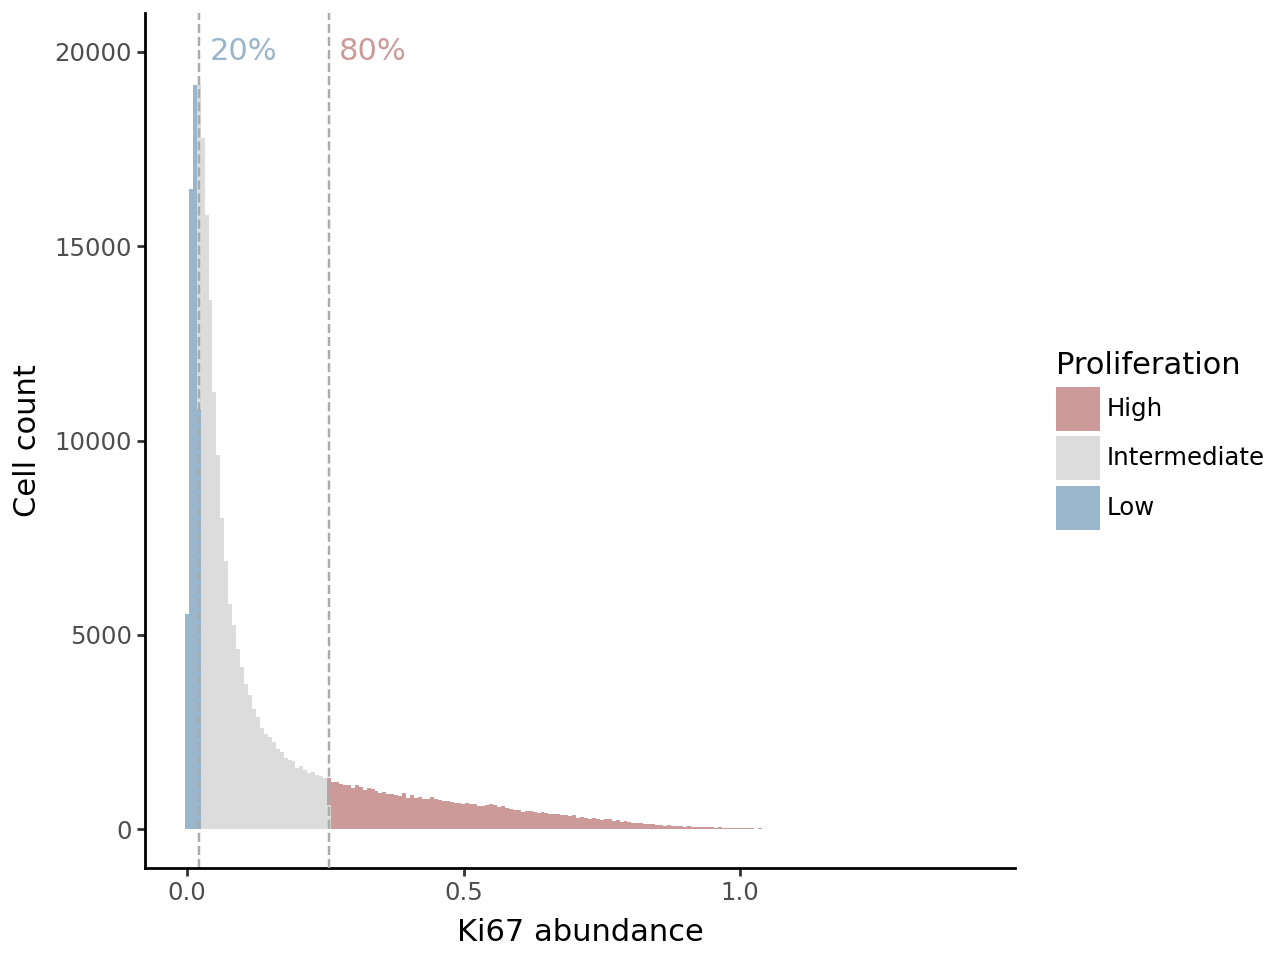

In [7]:
gp = (
    ggplot(df, aes(x="Ki67")) +
    geom_histogram(aes(fill="Aggressiveness"), bins=200) +
    scale_fill_manual(values=["#CC9B99",  "#dcdcdc", "#99B6CC"]) +
    theme_classic() +
    xlab("Ki67 abundance") +
    ylab("Cell count") +
    geom_vline(xintercept=agg_low, linetype="dashed", color="#acabab") +
    geom_vline(xintercept=agg_hi, linetype="dashed", color="#acabab") +
    annotate(geom="text", x=[0.08 + agg_low, 0.08 + agg_hi], y=20000, label=["20%", "80%"], 
             color=["#99B6CC", "#CC9B99"]) +
    guides(fill=guide_legend(title="Proliferation"))
)
gp

In [8]:
df["PanCK"] = adata[(adata.obs["annotation_consensus"] == "Cancer_cell") &
    (adata.obs["Stage"] != "SCT") &
    (adata.obs["Stage"] != "Colon-no.")].X[:,adata.var_names == "PanCK"].flatten().tolist()

In [9]:
all_metab_col = ['CA9', 'CD98', 'CytC', 'MSH2', 'MCT1', 'ASCT2',
       'LDH', 'GS', 'GLS', 'ATP5A', 'CS', 'PKM2', 'GLUT1', 'MSH6', 'ARG1', 'CPT1A']
meta_col = ["Aggressiveness", "Stage", "fov"]

/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 6 x 3 in image.
/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: ./figures/extrafig/intensity_ki67_cancer.pdf
/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_ydensity : Removed 586 rows containing non-finite values.
/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_ydensity : Removed 897 rows containing non-finite values.
/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_summary : Removed 1483 rows containing non-finite values.
/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_ydensity : Removed 586 rows containing non-finite values.
/home/loan/miniforge3/envs

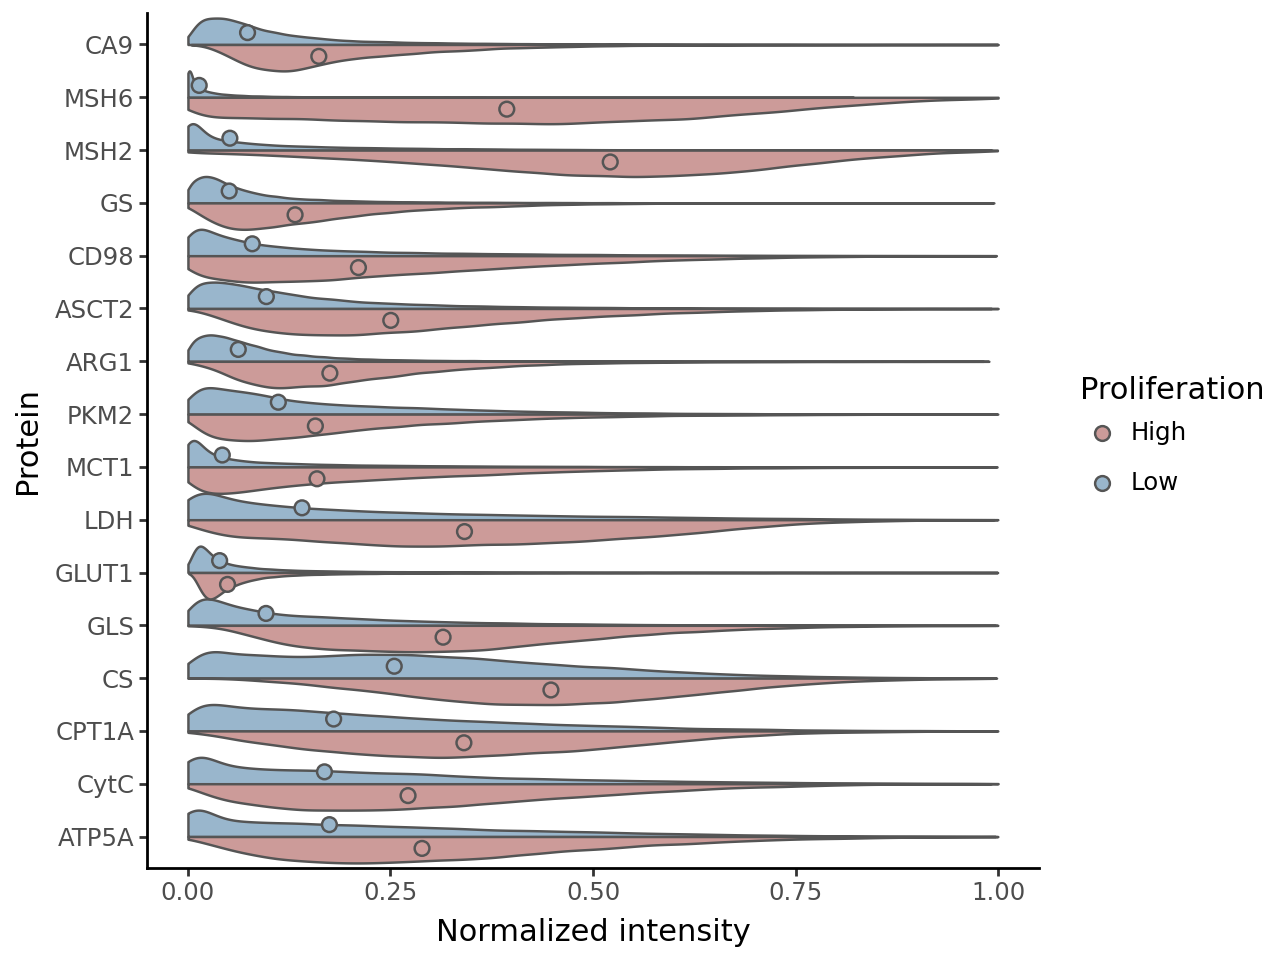

In [11]:
# Display violin plots of metabolic marker intensity per cell
# Split by aggressiveness (low = right violin, high = left violin)

# Convert to long format
df_long = pd.melt(df.loc[:,all_metab_col+meta_col], id_vars=meta_col, value_vars=all_metab_col)
# Reorder by pathway
path_order = ["ATP5A","CytC", "CPT1A", "CS", "GLS", "GLUT1", "LDH" ,"MCT1", "PKM2",
              "ARG1", "ASCT2", "CD98",  "GS", "MSH2", "MSH6", "CA9"]
df_long["variable"] = pd.Categorical(df_long["variable"], 
    categories=path_order,
    ordered=True)

gp = ggplot(df_long, aes(x="variable", y="value")) +\
    geom_violin(data=df_long.loc[df_long.Aggressiveness == "Low", :],
                fill="#99B6CC",
                color="#555555",
                style="right",
                scale="width",
                width=1) +\
    geom_violin(data=df_long.loc[df_long.Aggressiveness == "High", :],
                fill="#CC9B99",
                color="#555555",
                style="left",
                scale="width",
                width=1) +\
    stat_summary(data=df_long.loc[df_long.Aggressiveness != "Intermediate", :],
                 mapping=aes(fill="Aggressiveness"),
                 fun_y=np.median,
                 geom='point',
                 color="#555555",
                 position=position_dodge(width=0.9),
                 size=2.5) +\
    scale_fill_manual(values=["#CC9B99", "#99B6CC"]) +\
    theme_classic() +\
    coord_flip() +\
    ylab("Normalized intensity") +\
    xlab("Protein") +\
    ylim(0, 1) +\
    guides(fill=guide_legend(title="Proliferation"))

ggsave(gp, "./figures/extrafig/intensity_ki67_cancer.pdf", width = 6, height = 3)
gp

/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 6 x 3 in image.
/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: ./figures/fig3/intensity_ki67_healthy.pdf


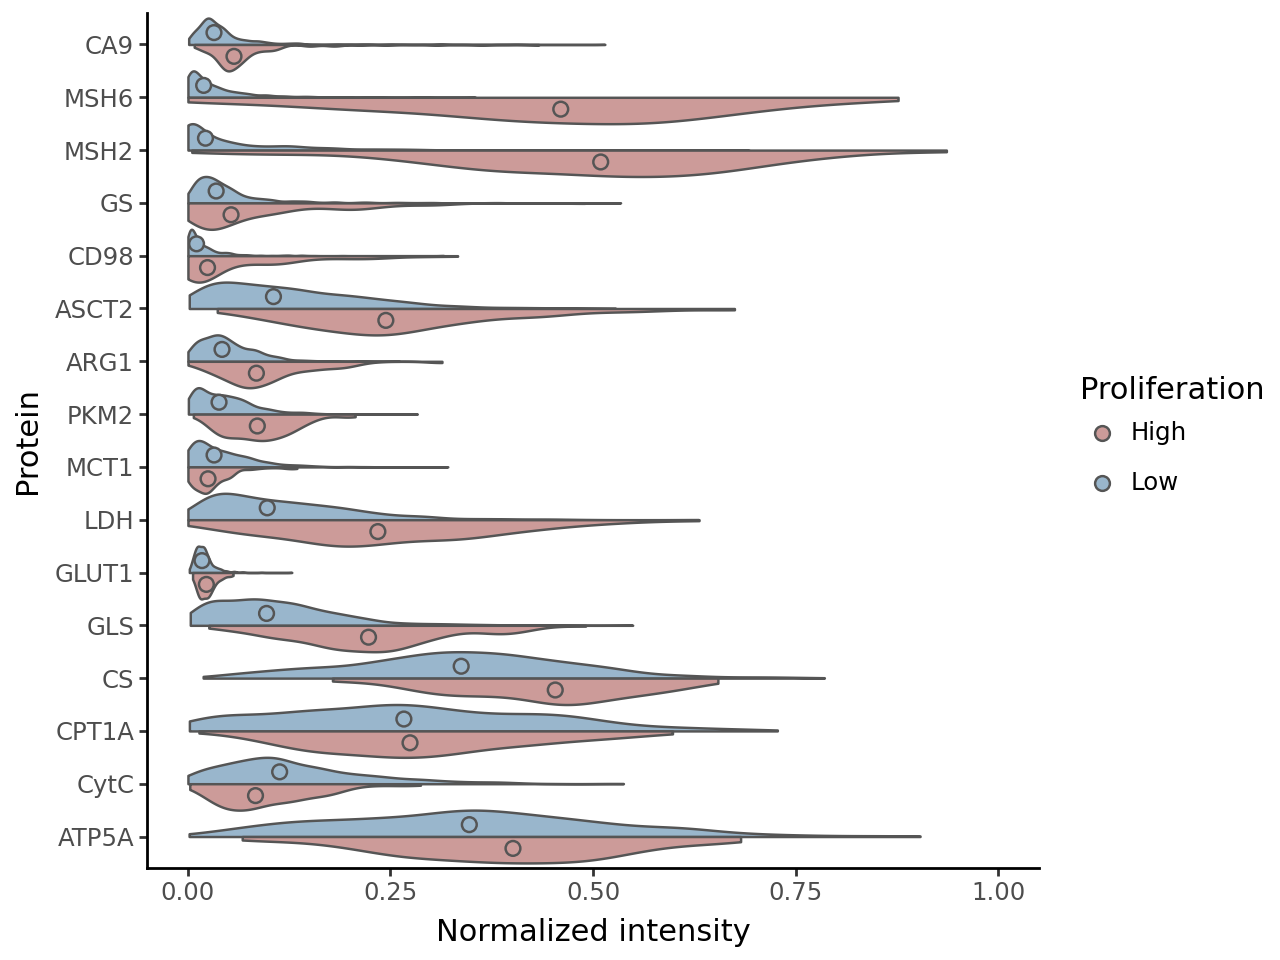

In [12]:
# Repeat for healthy stage
df = pd.DataFrame(adata[(adata.obs["annotation_consensus"] == "Cancer_cell") &
           (adata.obs["Stage"] == "Colon-no.")].obs)

# Thresholds are kept identical
df["Aggressiveness"] = ["High" if x > agg_hi else "Low" if x < agg_low else "Intermediate" for x in df["Ki67"]]

df["PanCK"] = adata[(adata.obs["annotation_consensus"] == "Cancer_cell") &
    (adata.obs["Stage"] == "Colon-no.")].X[:,adata.var_names == "PanCK"].flatten().tolist()

# Convert to long format
df_long = pd.melt(df.loc[:,all_metab_col+meta_col], id_vars=meta_col, value_vars=all_metab_col)
# Reorder by pathway
df_long["variable"] = pd.Categorical(df_long["variable"], 
    categories=path_order,
    ordered=True)

gp = ggplot(df_long, aes(x="variable", y="value")) +\
    geom_violin(data=df_long.loc[df_long.Aggressiveness == "Low", :],
                fill="#99B6CC",
                color="#555555",
                style="right",
                scale="width",
                width=1) +\
    geom_violin(data=df_long.loc[df_long.Aggressiveness == "High", :],
                fill="#CC9B99",
                color="#555555",
                style="left",
                scale="width",
                width=1) +\
    stat_summary(data=df_long.loc[df_long.Aggressiveness != "Intermediate", :],
                 mapping=aes(fill="Aggressiveness"),
                 fun_y=np.median,
                 geom="point",
                 color="#555555",
                 position=position_dodge(width=0.9),
                 size=2.5) +\
    scale_fill_manual(values=["#CC9B99", "#99B6CC"]) +\
    theme_classic() +\
    coord_flip() +\
    ylab("Normalized intensity") +\
    xlab("Protein") +\
    ylim(0, 1) +\
    guides(fill=guide_legend(title="Proliferation"))

ggsave(gp, "./figures/fig3/intensity_ki67_healthy.pdf", width=6, height=3)
gp

In [14]:
df = pd.DataFrame(adata[(adata.obs["annotation_consensus"] == "Cancer_cell") &
           (adata.obs["Stage"] != "SCT")].obs)

# Thresholds are kept identical
df["Aggressiveness"] = ["High" if x > agg_hi else "Low" if x < agg_low else "Intermediate" for x in df["Ki67"]]

df = df.loc[df.Aggressiveness != "Intermediate"]

In [15]:
adata[(adata.obs["Stage"] != "SCT")].obs

,CA9,nuclei,CD98,CytC,MSH2,MCT1,PDL1,PD1,ASCT2,LDH,...,RAS Mutation RED,RAS Mutation RED 2,BRAF Mutation RED,HER2 Amplifikation,Age,Sex,MIBI,Tumor Size Group,Age Group,Stage
0,0.021289,0.046148,0.006393,0.015713,0.024734,0.000193,0.009023,0.004550,0.045864,0.013713,...,NaN,NaN,NaN,NaN,88.0,w,acquired,NaN,70 and Over,pT3
1,0.014578,0.034238,0.008831,0.106513,0.063474,0.002774,0.004173,0.000000,0.028734,0.002855,...,NaN,NaN,NaN,NaN,88.0,w,acquired,NaN,70 and Over,pT3
2,0.113299,0.064198,0.034138,0.011429,0.066563,0.001506,0.009498,0.000000,0.028260,0.013809,...,NaN,NaN,NaN,NaN,88.0,w,acquired,NaN,70 and Over,pT3
3,0.128277,0.097153,0.040913,0.030368,0.016016,0.005280,0.022267,0.028413,0.034091,0.032231,...,NaN,NaN,NaN,NaN,88.0,w,acquired,NaN,70 and Over,pT3
4,0.107682,0.054147,0.070130,0.098551,0.081037,0.020924,0.004454,0.022994,0.117576,0.035627,...,NaN,NaN,NaN,NaN,88.0,w,acquired,NaN,70 and Over,pT3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
579942,0.025945,0.044181,0.021980,0.034234,0.004055,0.007513,0.094103,0.107648,0.274624,0.050588,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Colon-no.
579943,0.052626,0.187155,0.222263,0.000000,0.000000,0.026086,0.083621,0.072199,0.089165,0.232087,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Colon-no.
579944,0.063988,0.164008,0.131201,0.082124,0.002103,0.010024,0.013886,0.008995,0.240087,0.120408,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Colon-no.
579945,0.037612,0.188549,0.035632,0.035699,0.041807,0.029209,0.117594,0.038083,0.087450,0.285066,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Colon-no.


In [13]:
agg_counts = (
    df.groupby(["fov", "Stage", "Aggressiveness"])
      .size()
      .unstack("Aggressiveness", fill_value=0)
)

keep_pairs = agg_counts.loc[
    (agg_counts.get("High", 0) >= 3) & (agg_counts.get("Low", 0) >= 3),
    :
].reset_index()[["fov", "Stage"]]


df_filt = df.merge(keep_pairs, on=["fov", "Stage"], how="inner")

# Pseudobulk (median) per aggressiveness within each kept (fov, Stage)
pseudobulk_df = (
    df_filt.loc[:, all_metab_col + ["Aggressiveness", "fov", "Stage"]]
          .groupby(["Aggressiveness", "fov", "Stage"])
          .median()
          .reset_index()
)

/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 4 x 2.5 in image.
/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: ./figures/extrafig/mct1_aggressiveness_scatter.pdf


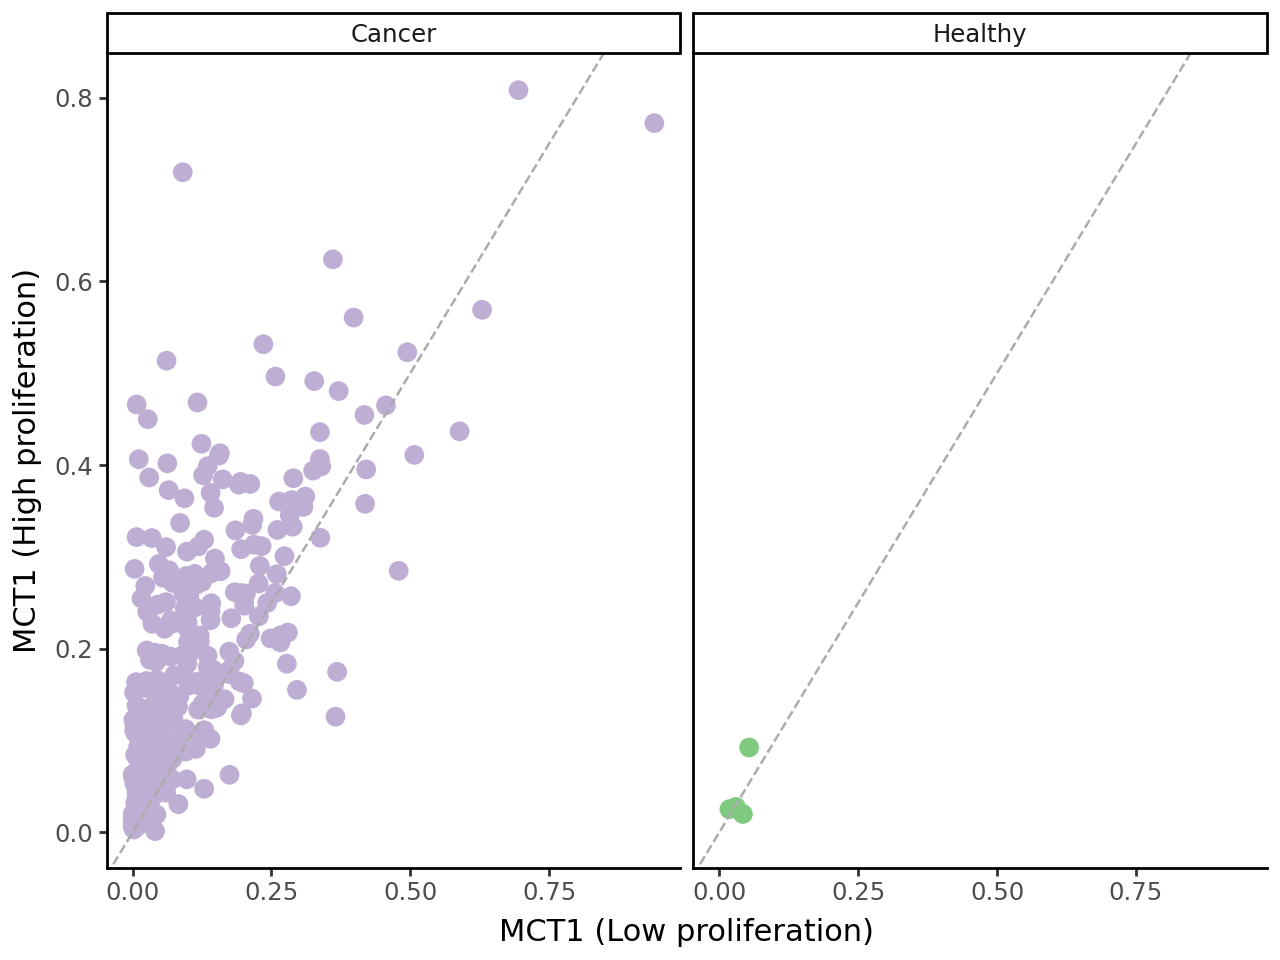

In [14]:
# Display the paired values
paired_df = (pseudobulk_df
    .pivot_table(
        index=["fov","Stage"],
        columns="Aggressiveness",
        values="MCT1"
    ) )

paired_df["Cancer"] = ["Healthy" if x == "Colon-no." else "Cancer" for x in paired_df.index.get_level_values("Stage")]

gp = (ggplot(paired_df.reset_index(), aes(x="Low", y="High", color="Cancer") )
    + geom_point(size = 3)
    + geom_abline(slope=1, intercept=0, linetype="dashed", color="#acabab")
    + theme_classic()
    + labs(x="MCT1 (Low proliferation)", y="MCT1 (High proliferation)")
    + scale_color_manual(values=["#beaed4", "#7fc980"])
    + theme(legend_position='none')
    + facet_wrap("~Cancer")
)

ggsave(gp, "./figures/extrafig/mct1_aggressiveness_scatter.pdf", width=4, height=2.5)
gp

/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 4 x 2.5 in image.
/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: ./figures/extrafig/ldh_aggressiveness_scatter.pdf


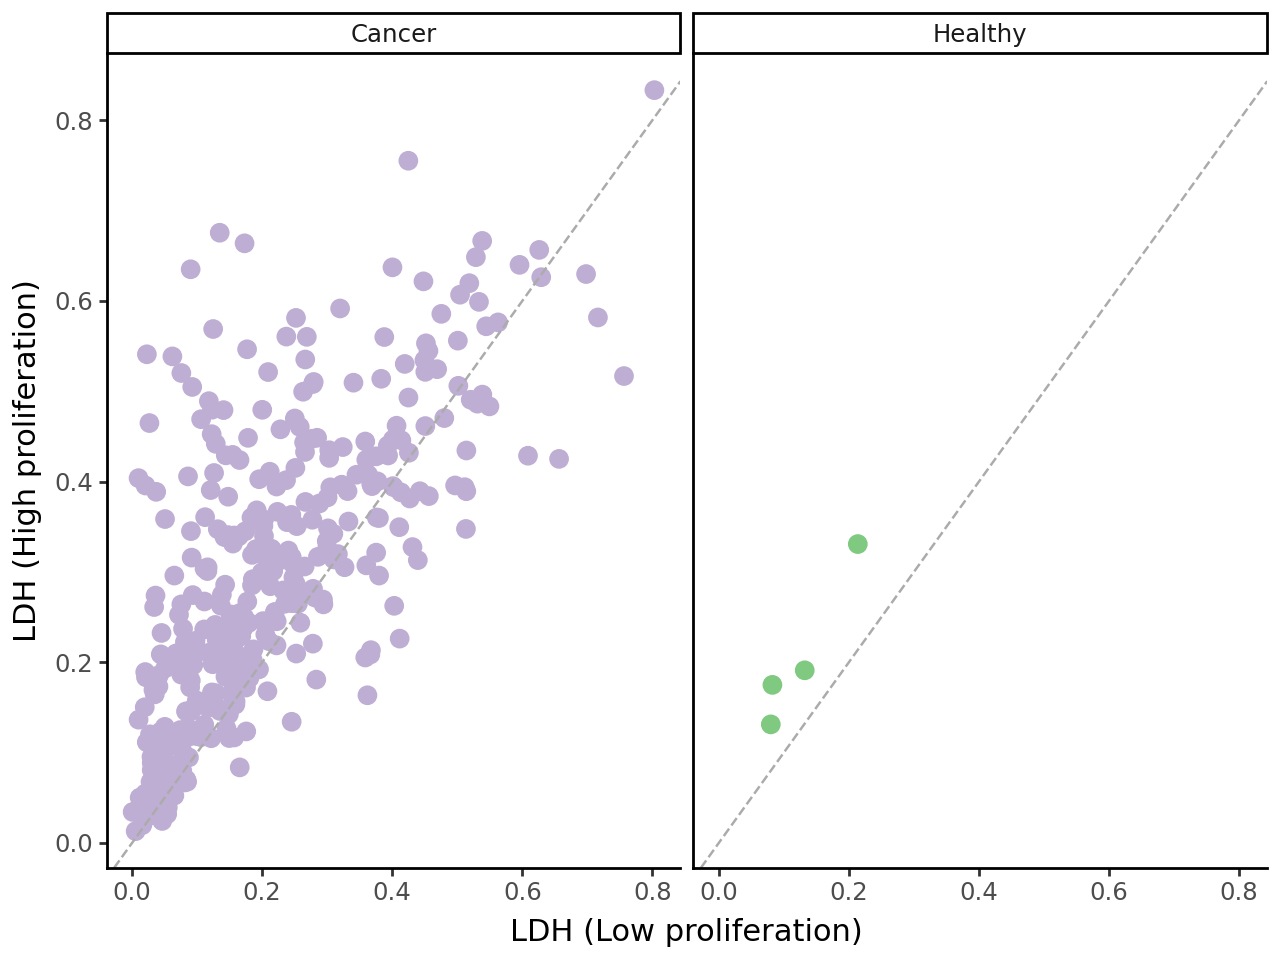

In [15]:
# Display the paired values for CD98
paired_df = (pseudobulk_df
    .pivot_table(
        index=["fov","Stage"],
        columns="Aggressiveness",
        values="LDH"
    ) )

paired_df["Cancer"] = ["Healthy" if x == "Colon-no." else "Cancer" for x in paired_df.index.get_level_values("Stage")]

gp = (ggplot(paired_df.reset_index(), aes(x="Low", y="High", color="Cancer") )
    + geom_point(size = 3)
    + geom_abline(slope=1, intercept=0, linetype="dashed", color="#acabab")
    + theme_classic()
    + labs(x="LDH (Low proliferation)", y="LDH (High proliferation)")
    + scale_color_manual(values=["#beaed4", "#7fc980"])
    + theme(legend_position='none')
    + facet_wrap("~Cancer")
)

ggsave(gp, "./figures/extrafig/ldh_aggressiveness_scatter.pdf", width=4, height=2.5)
gp

In [16]:
from scipy.stats import mannwhitneyu, false_discovery_control

# Avoid log of zero or negative values
eps = 1e-9

# Store p-values
pval_dict = {}

# for protein in all_metab_col:
for protein in ["LDH","MCT1"]: # Targeted analysis
    print(f"Analyzing protein: {protein}")
    
    # Get paired measurements
    paired_df = (pseudobulk_df
        .pivot_table(
            index=["fov","Stage"],
            columns="Aggressiveness",
            values=protein
        )).reset_index()

    # Add cancer status and logFC columns
    paired_df["Cancer"] = pd.Categorical(["Healthy" if x == "Colon-no." else "Cancer" 
                           for x in paired_df["Stage"]],
                           categories=["Healthy", "Cancer"], ordered=True)

    paired_df["FC_prolif"] = (paired_df["High"] + eps) / (paired_df["Low"] + eps)
    paired_df["logFC_prolif"] = np.log2(paired_df["High"] + eps) - np.log2(paired_df["Low"] + eps)
    
    # When there's an increase in metabolic activity in aggressive cells
    if ((paired_df[paired_df.Cancer == "Cancer"]["FC_prolif"].median() < 1.5) and 
       (paired_df[paired_df.Cancer == "Healthy"]["FC_prolif"].median() < 1.5)):
        print(f"Skipping {protein} due to insufficient FC increase ({paired_df[paired_df.Cancer == 'Cancer']['FC_prolif'].median()}, {paired_df[paired_df.Cancer == 'Healthy']['FC_prolif'].median()}).")
        continue

    # Perform median test
    stat, p = mannwhitneyu(
        paired_df.loc[paired_df.Cancer == "Cancer", "logFC_prolif"],
        paired_df.loc[paired_df.Cancer == "Healthy", "logFC_prolif"]
    )

    print(f"Mann-Whitney U test p-value for {protein}: {p}")

    pval_dict[protein] = p

# Compute FDR
pd.DataFrame({
    "Protein": pval_dict.keys(),
    "FDR": false_discovery_control(
        list(pval_dict.values()),
        method="bh"
    )})

Analyzing protein: LDH
Mann-Whitney U test p-value for LDH: 0.4463740058538252
Analyzing protein: MCT1
Mann-Whitney U test p-value for MCT1: 0.05106117776227814


,Protein,FDR
0,LDH,0.446374
1,MCT1,0.102122
